# Transfer Learning with Frozen ResNet-18

This notebook trains a pretrained ResNet-18 on the DeepWeeds dataset using transfer learning. The ResNet-18 backbone is frozen, and only the final classification layer is trained on the DeepWeeds classes.

In [1]:
import os
import copy
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

BASE_DIR = os.path.expanduser("~/Developer/curtin/NNSML/datasets/DeepWeeds")
IMAGES_DIR = os.path.join(BASE_DIR, "images")
LABELS_DIR = os.path.join(BASE_DIR, "labels")

TRAIN_CSV = os.path.join(LABELS_DIR, "train_subset0.csv")
VAL_CSV = os.path.join(LABELS_DIR, "val_subset0.csv")
TEST_CSV = os.path.join(LABELS_DIR, "test_subset0.csv")

RESULTS_DIR = "../results"
FIGURES_DIR = os.path.join(RESULTS_DIR, "figures")
TABLES_DIR = os.path.join(RESULTS_DIR, "tables")
CHECKPOINTS_DIR = os.path.join(RESULTS_DIR, "checkpoints")

os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)
os.makedirs(CHECKPOINTS_DIR, exist_ok=True)

CLASS_NAMES = [
    "Chinee Apple",
    "Lantana",
    "Parkinsonia",
    "Parthenium",
    "Prickly Acacia",
    "Rubber Vine",
    "Siam Weed",
    "Snake Weed",
    "Negatives",
]

NUM_CLASSES = len(CLASS_NAMES)
IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

Using device: cpu


In [4]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

for split_df in [train_df, val_df, test_df]:
    split_df["image_path"] = split_df["Filename"].apply(lambda x: os.path.join(IMAGES_DIR, x))
    split_df["label"] = split_df["Label"].astype(int)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)


Train: (10501, 4)
Val: (3501, 4)
Test: (3507, 4)


In [11]:
weights = ResNet18_Weights.DEFAULT

weights_transforms = weights.transforms()
weights.meta["mean"] = weights_transforms.mean
weights.meta["std"] = weights_transforms.std

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [12]:
class DeepWeedsDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label

In [13]:
train_dataset = DeepWeedsDataset(train_df, transform=train_transform)
val_dataset = DeepWeedsDataset(val_df, transform=eval_transform)
test_dataset = DeepWeedsDataset(test_df, transform=eval_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 329
Val batches: 110
Test batches: 110


In [14]:
images, labels = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Sample labels:", labels[:10].tolist())

Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Sample labels: [4, 8, 8, 8, 8, 7, 5, 4, 7, 8]


In [15]:
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, NUM_CLASSES)

model = model.to(DEVICE)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/rashmikecaldera/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 36.6MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [16]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(f"Trainable parameters: {trainable_params:,}")
print(f"Total parameters: {total_params:,}")

Trainable parameters: 4,617
Total parameters: 11,181,129


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1

In [19]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average="macro", zero_division=0
    )

    return epoch_loss, epoch_acc, precision, recall, f1, all_labels, all_preds

In [20]:
history = {
    "train_loss": [],
    "train_acc": [],
    "train_f1": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
}

best_model_wts = copy.deepcopy(model.state_dict())
best_val_f1 = -1.0

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc, train_prec, train_rec, train_f1 = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    val_loss, val_acc, val_prec, val_rec, val_f1, _, _ = evaluate(
        model, val_loader, criterion, DEVICE
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["train_f1"].append(train_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), os.path.join(CHECKPOINTS_DIR, "resnet18_frozen_best.pth"))

    print(
        f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
        f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}, Val F1: {val_f1:.4f}"
    )

elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed/60:.2f} minutes")

Epoch [1/10] | Train Loss: 1.1814, Train Acc: 0.6040, Train F1: 0.3888 | Val Loss: 0.9186, Val Acc: 0.6824, Val F1: 0.5389
Epoch [2/10] | Train Loss: 0.8862, Train Acc: 0.6931, Train F1: 0.5733 | Val Loss: 0.8162, Val Acc: 0.7109, Val F1: 0.5788
Epoch [3/10] | Train Loss: 0.8301, Train Acc: 0.7097, Train F1: 0.6016 | Val Loss: 0.7796, Val Acc: 0.7324, Val F1: 0.6382
Epoch [4/10] | Train Loss: 0.8057, Train Acc: 0.7179, Train F1: 0.6140 | Val Loss: 0.7643, Val Acc: 0.7312, Val F1: 0.6421
Epoch [5/10] | Train Loss: 0.7712, Train Acc: 0.7335, Train F1: 0.6393 | Val Loss: 0.7565, Val Acc: 0.7355, Val F1: 0.6557
Epoch [6/10] | Train Loss: 0.7559, Train Acc: 0.7337, Train F1: 0.6419 | Val Loss: 0.7266, Val Acc: 0.7509, Val F1: 0.6493
Epoch [7/10] | Train Loss: 0.7408, Train Acc: 0.7392, Train F1: 0.6531 | Val Loss: 0.7276, Val Acc: 0.7449, Val F1: 0.6473
Epoch [8/10] | Train Loss: 0.7428, Train Acc: 0.7407, Train F1: 0.6553 | Val Loss: 0.6883, Val Acc: 0.7589, Val F1: 0.6811
Epoch [9/10] | T

In [21]:
model.load_state_dict(best_model_wts)
print("Loaded best model based on validation macro F1.")

Loaded best model based on validation macro F1.


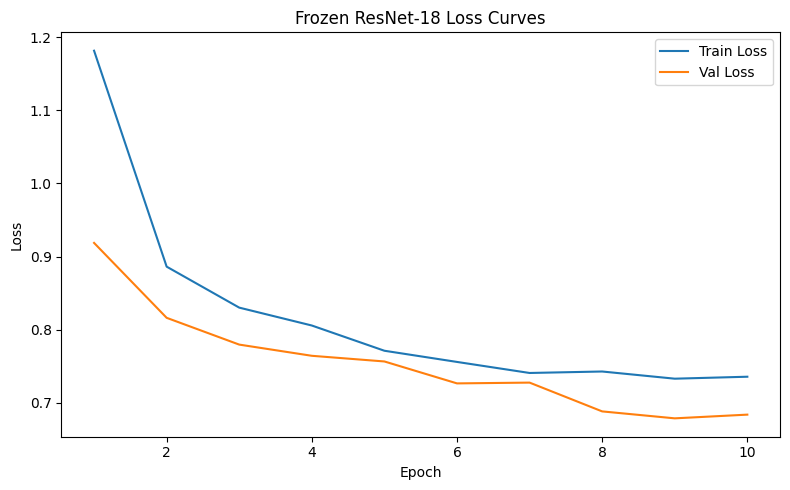

In [22]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Frozen ResNet-18 Loss Curves")
plt.legend()
plt.tight_layout()
plt.show()

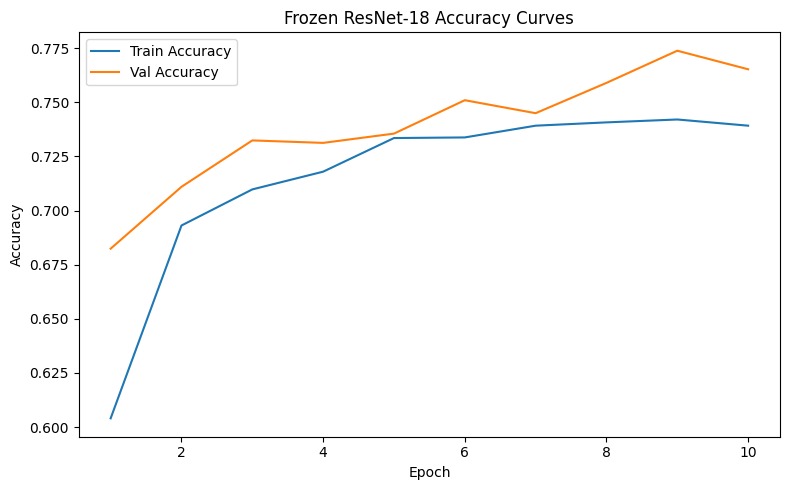

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Train Accuracy")
plt.plot(epochs, history["val_acc"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Frozen ResNet-18 Accuracy Curves")
plt.legend()
plt.tight_layout()
plt.show()

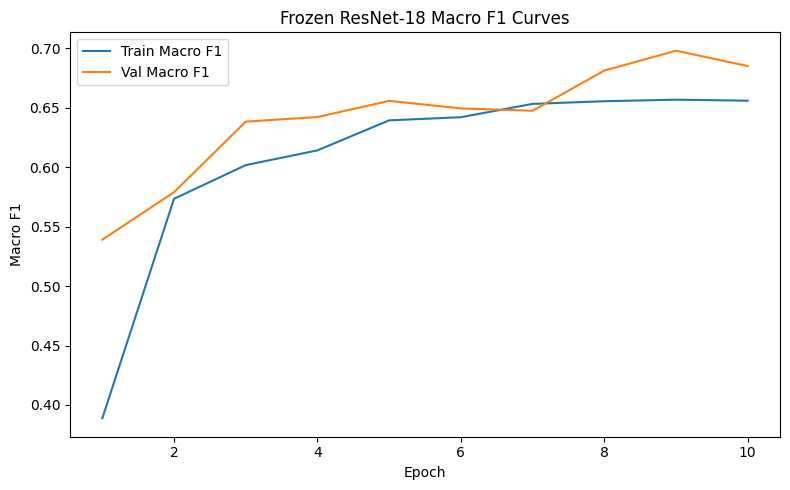

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_f1"], label="Train Macro F1")
plt.plot(epochs, history["val_f1"], label="Val Macro F1")
plt.xlabel("Epoch")
plt.ylabel("Macro F1")
plt.title("Frozen ResNet-18 Macro F1 Curves")
plt.legend()
plt.tight_layout()
plt.show()

In [25]:
test_loss, test_acc, test_prec, test_rec, test_f1, y_true, y_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Macro Precision: {test_prec:.4f}")
print(f"Test Macro Recall: {test_rec:.4f}")
print(f"Test Macro F1: {test_f1:.4f}")

Test Loss: 0.6917
Test Accuracy: 0.7645
Test Macro Precision: 0.7445
Test Macro Recall: 0.6394
Test Macro F1: 0.6757


In [26]:
report = classification_report(
    y_true,
    y_pred,
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
Chinee Apple,0.693182,0.539823,0.606965,226.000000
Lantana,0.741176,0.591549,0.657963,213.000000
Parkinsonia,0.752294,0.792271,0.771765,207.000000
Parthenium,0.703226,0.531707,0.605556,205.000000
Prickly Acacia,0.800000,0.732394,0.764706,213.000000
Rubber Vine,0.685279,0.668317,0.676692,202.000000
Siam Weed,0.744898,0.679070,0.710462,215.000000
Snake Weed,0.797468,0.308824,0.445230,204.000000
Negatives,0.782650,0.911087,0.841998,1822.000000
accuracy,0.764471,0.764471,0.764471,0.764471


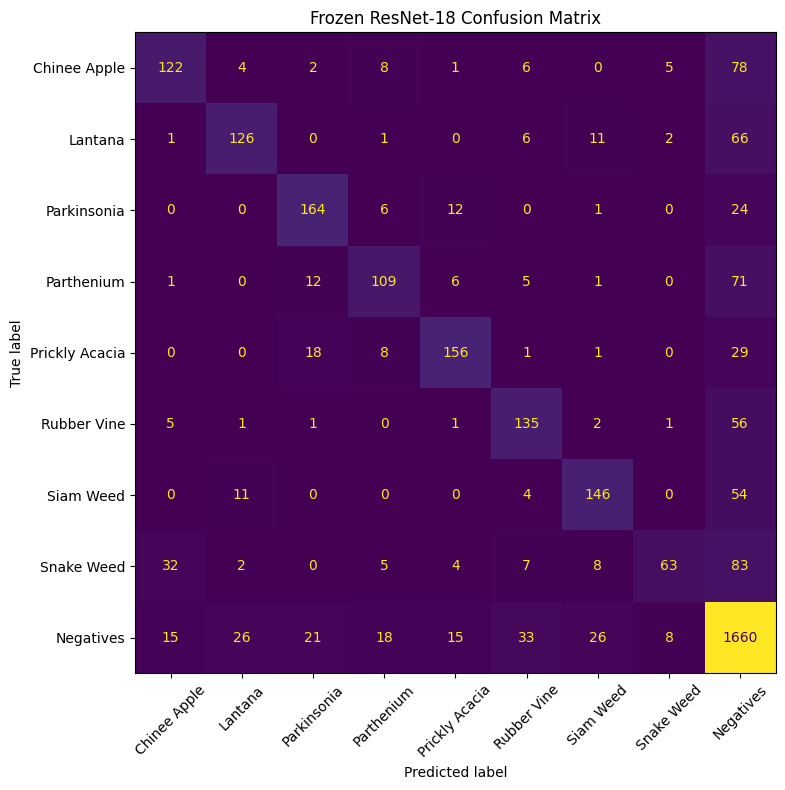

In [27]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Frozen ResNet-18 Confusion Matrix")
plt.tight_layout()
plt.show()

In [28]:
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(TABLES_DIR, "resnet18_frozen_history.csv"), index=False)

report_df.to_csv(os.path.join(TABLES_DIR, "resnet18_frozen_classification_report.csv"))

np.savetxt(
    os.path.join(TABLES_DIR, "resnet18_frozen_confusion_matrix.csv"),
    cm,
    delimiter=",",
    fmt="%d"
)

summary_df = pd.DataFrame([{
    "model": "ResNet18_Frozen",
    "epochs": NUM_EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "best_val_f1": best_val_f1,
    "test_loss": test_loss,
    "test_accuracy": test_acc,
    "test_macro_precision": test_prec,
    "test_macro_recall": test_rec,
    "test_macro_f1": test_f1,
    "training_time_minutes": elapsed / 60,
}])

summary_df.to_csv(os.path.join(TABLES_DIR, "resnet18_frozen_summary.csv"), index=False)

print("Saved frozen ResNet-18 outputs.")

Saved frozen ResNet-18 outputs.


In [29]:
baseline_summary_path = os.path.join(TABLES_DIR, "baseline_cnn_summary.csv")

if os.path.exists(baseline_summary_path):
    baseline_summary = pd.read_csv(baseline_summary_path)
    frozen_summary = summary_df.copy()

    comparison_df = pd.concat([baseline_summary, frozen_summary], ignore_index=True)
    comparison_df
else:
    print("Baseline summary file not found. Run the baseline notebook first.")

## Frozen ResNet-18 Observations

- The frozen ResNet-18 model substantially outperformed the baseline CNN.
- Test accuracy improved from 0.5723 to 0.7645, while macro F1 improved from 0.2181 to 0.6757.
- This shows that transfer learning provided much stronger visual features than the custom CNN trained from scratch.
- Unlike the baseline, the frozen ResNet-18 achieved useful recall and F1-scores across most weed classes rather than mainly predicting the Negatives class.
- The confusion matrix still shows some confusion with the Negatives class, but this problem is much less severe than in the baseline model.
- Snake Weed remained the most difficult class, with noticeably lower recall than the other classes.
- Overall, the results strongly support the use of transfer learning for this dataset.